# Analisis Sentimen Ulasan Aplikasi Gojek (Google Play Store)

**Proyek:** Sentiment Analysis – Belajar Fundamental Deep Learning  
**Dataset:** Ulasan Gojek dari Google Play Store (≥ 11.000 ulasan)  
**Kelas:** Negatif / Positif  
**Skema Pelatihan:**
| # | Algoritma | Ekstraksi Fitur | Split |
|---|-----------|-----------------|-------|
| 1 | SVM (LinearSVC) | TF-IDF | 80/20 |
| 2 | Random Forest | Word2Vec | 80/20 |
| 3 | IndoBERT (Transformer) | BERT Tokenizer | 80/20 |

**Target Akurasi:** ≥ 92% pada test set

## 1. Import Libraries

In [22]:
import os, re, time, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"]  = 11
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EvalPrediction,
)
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


## 2. Load Dataset & Exploratory Data Analysis (EDA)

In [31]:
df = pd.read_csv("dataset_gojek.csv")
display(df.head())
df.info()
print("\nMissing values:\n", df.isnull().sum())


,review_id,user_name,review,rating,thumbs_up,date,sentiment
0,13003426-22fd-4bb8-a4df-7fe8206dd398,Hanna Febriana,20.02.26 21.00 apk tidak bisa di download. Ber...,1,0,2026-02-20 21:32:38,negatif
1,9ba2f9e1-1884-445a-89f1-54cd938da947,Ahe Belajarbaca,"dari tahun 2007 pake gojek, mohon maaf saya pu...",1,0,2026-02-20 21:26:07,negatif
2,64a8a02f-6525-4d8f-a50a-79e61a6333f8,Hamidah santi Lestari,DRIVER SEKARANG PADA BANYAK NGIBUL!! DAN PADA ...,2,0,2026-02-20 21:11:47,negatif
3,c944a007-f07c-4af1-8168-fbb927cb05f6,Pajri Chenel,bagus,5,0,2026-02-20 20:53:56,positif
4,714289ea-c28b-45f8-985d-b0f3ba1a2eea,Triana Puji Astuti,driver skrng bnyk yg ngk jls. aplikasi on TPI ...,1,0,2026-02-20 20:46:53,negatif


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  12000 non-null  object
 1   user_name  12000 non-null  object
 2   review     12000 non-null  object
 3   rating     12000 non-null  int64 
 4   thumbs_up  12000 non-null  int64 
 5   date       12000 non-null  object
 6   sentiment  12000 non-null  object
dtypes: int64(2), object(5)
memory usage: 656.4+ KB

Missing values:
 review_id    0
user_name    0
review       0
rating       0
thumbs_up    0
date         0
sentiment    0
dtype: int64


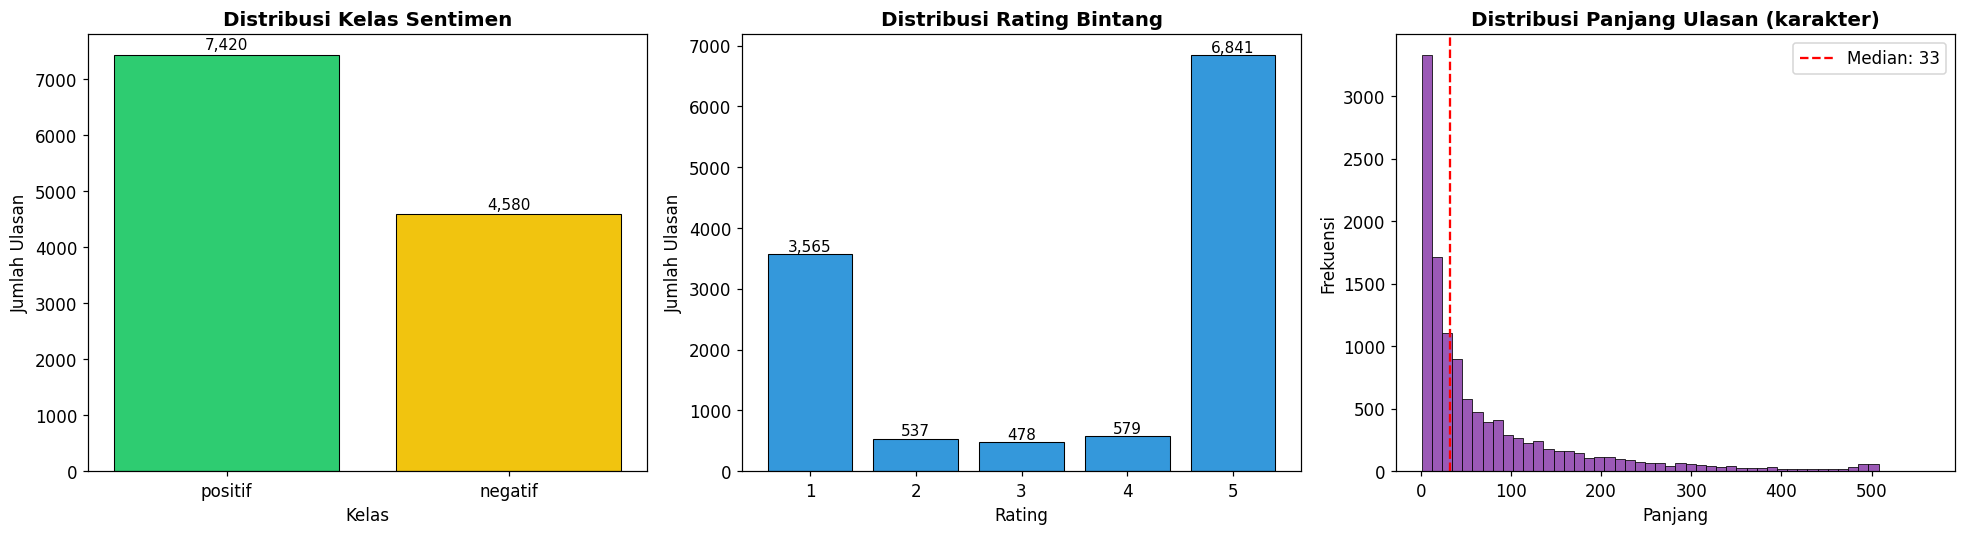


Statistik panjang ulasan:
count    12000.00
mean        73.66
std         98.33
min          1.00
25%         11.00
50%         33.00
75%         95.00
max        564.00
Name: review_len, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribusi Kelas Sentimen
order = ["positif", "negatif"]
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]
counts = df["sentiment"].value_counts().reindex(order)
axes[0].bar(order, counts.values, color=colors, edgecolor="black", linewidth=0.7)
axes[0].set_title("Distribusi Kelas Sentimen", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Ulasan")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontsize=10)

# 2. Distribusi Rating Bintang
rating_counts = df["rating"].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values,
            color="#3498db", edgecolor="black", linewidth=0.7)
axes[1].set_title("Distribusi Rating Bintang", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Jumlah Ulasan")
for i, v in enumerate(rating_counts.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=10)

# 3. Distribusi Panjang Ulasan
df["review_len"] = df["review"].astype(str).apply(len)
axes[2].hist(df["review_len"], bins=50, color="#9b59b6", edgecolor="black", linewidth=0.5)
axes[2].set_title("Distribusi Panjang Ulasan (karakter)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Panjang")
axes[2].set_ylabel("Frekuensi")
axes[2].axvline(df["review_len"].median(), color="red", linestyle="--", label=f"Median: {df['review_len'].median():.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nStatistik panjang ulasan:")
print(df["review_len"].describe().round(2))


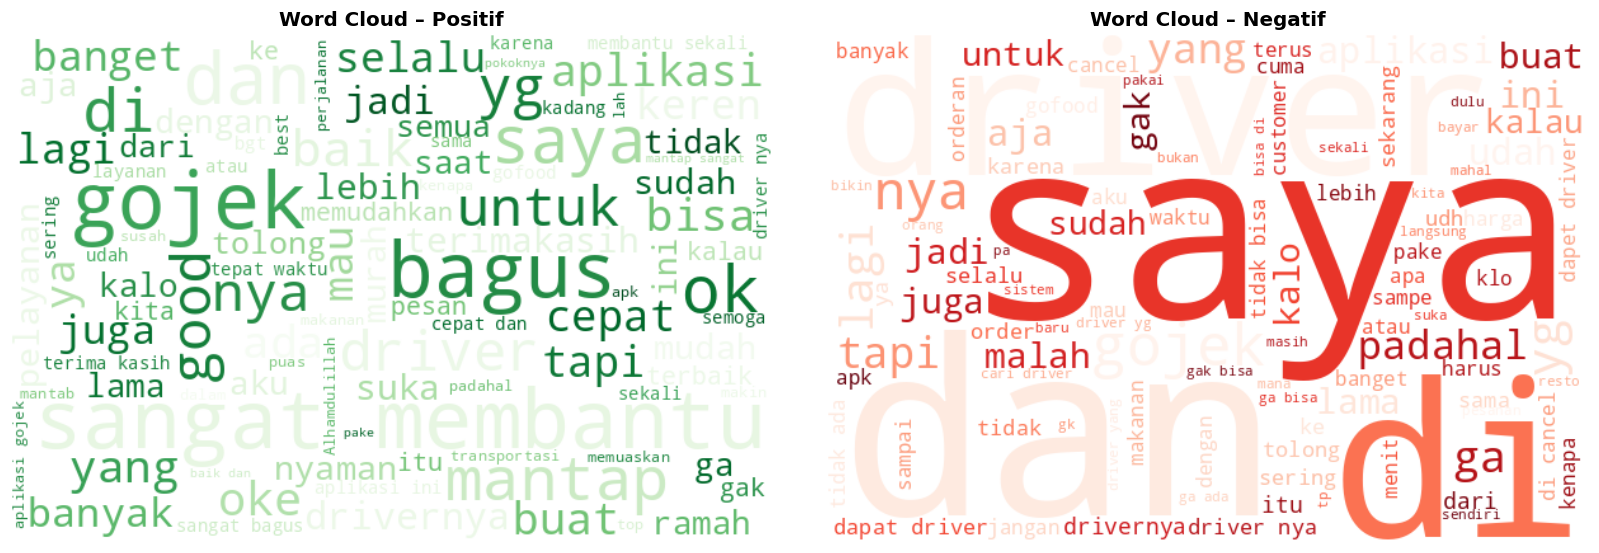

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (cls, color) in zip(axes, [("positif", "Greens"), ("negatif", "Reds")]):
    text = " ".join(df[df["sentiment"] == cls]["review"].astype(str).tolist())
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud – {cls.capitalize()}", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 3. Preprocessing & Text Cleaning

Pipeline:
1. Lowercase
2. Hapus URL, HTML, emoji, angka, tanda baca
3. Hapus stop words (Bahasa Indonesia – NLTK + Sastrawi)
4. Stemming menggunakan **Sastrawi**

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

sw_factory = StopWordRemoverFactory()
sastrawi_stopwords = set(sw_factory.get_stop_words())


try:
    nltk_stopwords = set(stopwords.words("indonesian"))
except:
    nltk_stopwords = set()

all_stopwords = sastrawi_stopwords | nltk_stopwords

# Tambahan stopwords kustom
custom_sw = {"yg", "nya", "aja", "udah", "gak", "ga", "deh", "sih",
             "dong", "kan", "lho", "loh", "tuh", "nah", "ih", "eh",
             "app", "aplikasi", "gojek", "ojek"}
all_stopwords |= custom_sw

print(f"Total stopwords: {len(all_stopwords)}")

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)      
    text = re.sub(r"<.*?>", " ", text)                  
    text = re.sub(r"[^\x00-\x7F\u00C0-\u024F]", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)              
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text: str, do_stem: bool = True) -> str:
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 1]
    if do_stem:
        tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

Total stopwords: 791


In [9]:
tqdm.pandas(desc="Preprocessing")
df["clean_review"] = df["review"].progress_apply(lambda x: preprocess(x, do_stem=True))

# Hapus baris kosong setelah preprocessing
df = df[df["clean_review"].str.strip() != ""].reset_index(drop=True)
print(f"\nTotal baris setelah preprocessing: {len(df):,}")
display(df[["review","clean_review","sentiment"]].head(5))


Preprocessing: 100%|██████████| 12000/12000 [08:27<00:00, 23.67it/s] 


Total baris setelah preprocessing: 11,355


,review,clean_review,sentiment
0,20.02.26 21.00 apk tidak bisa di download. Ber...,apk download henti kacau sistem aplikasi,negatif
1,"dari tahun 2007 pake gojek, mohon maaf saya pu...",pake mohon maaf putus rating buruk utk apk kec...,negatif
2,DRIVER SEKARANG PADA BANYAK NGIBUL!! DAN PADA ...,driver ngibul uang tdk nyaman pakai,negatif
3,bagus,bagus,positif
4,driver skrng bnyk yg ngk jls. aplikasi on TPI ...,driver skrng bnyk ngk jls on tpi ngk pick up c...,negatif


In [14]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["sentiment"])

print(f"Kelas Label: {le.classes_}")
print(f"Mapping: { {cls: idx for idx, cls in enumerate(le.classes_)} }")
print(df[["sentiment", "label"]].value_counts())

Kelas Label: ['negatif' 'positif']
Mapping: {'negatif': 0, 'positif': 1}
sentiment  label
positif    1        6794
negatif    0        4561
Name: count, dtype: int64


## 4. Ekstraksi Fitur & Pembagian Data (Train/Test Split 80/20)

### 4.1 TF-IDF


Digunakan untuk **Skema 1 (SVM)**.

### 4.2 Word2Vec
Digunakan untuk **Skema 2 (Random Forest)**.

In [15]:
X_text  = df["clean_review"].values
y       = df["sentiment"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train_text):,}  |  Test: {len(X_test_text):,}")

print("\n[TF-IDF] Fitting vectorizer...")
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
print(f"TF-IDF shape: train={X_train_tfidf.shape}, test={X_test_tfidf.shape}")


print("\n[Word2Vec] Training model...")
tokenized_corpus = [t.split() for t in X_text]
w2v = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42,
)

def text_to_w2v(text, model, size=100):
    tokens = text.split()
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_train_w2v = np.array([text_to_w2v(t, w2v) for t in X_train_text])
X_test_w2v  = np.array([text_to_w2v(t, w2v) for t in X_test_text])
print(f"Word2Vec shape: train={X_train_w2v.shape}, test={X_test_w2v.shape}")


Train: 9,084  |  Test: 2,271

[TF-IDF] Fitting vectorizer...
TF-IDF shape: train=(9084, 4330), test=(2271, 4330)

[Word2Vec] Training model...
Word2Vec shape: train=(9084, 100), test=(2271, 100)


---
## Skema 1: SVM + TF-IDF (Split 80/20)

**Algoritma:** Support Vector Machine (`LinearSVC`)  
**Ekstraksi Fitur:** TF-IDF (unigram + bigram, max_features=30.000)  
**Split:** 80% train / 20% test

SKEMA 1: SVM + TF-IDF
Akurasi Train   : 0.9661 (96.61%)
Akurasi Test    : 0.9053  (90.53%)

Classification Report (Test):
              precision    recall  f1-score   support

     negatif       0.89      0.88      0.88       912
     positif       0.92      0.92      0.92      1359

    accuracy                           0.91      2271
   macro avg       0.90      0.90      0.90      2271
weighted avg       0.91      0.91      0.91      2271



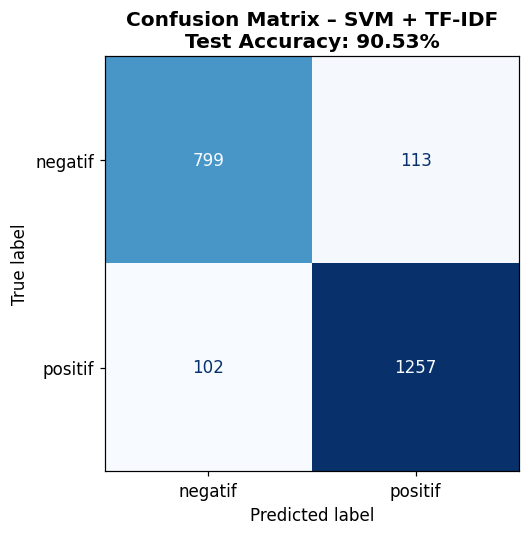

In [16]:

print("SKEMA 1: SVM + TF-IDF")

svm_model = LinearSVC(C=1.0, max_iter=3000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm_train = svm_model.predict(X_train_tfidf)
y_pred_svm_test  = svm_model.predict(X_test_tfidf)

acc_svm_train = accuracy_score(y_train, y_pred_svm_train)
acc_svm_test  = accuracy_score(y_test,  y_pred_svm_test)

print(f"Akurasi Train   : {acc_svm_train:.4f} ({acc_svm_train*100:.2f}%)")
print(f"Akurasi Test    : {acc_svm_test:.4f}  ({acc_svm_test*100:.2f}%)")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_svm_test, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_svm_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix – SVM + TF-IDF\nTest Accuracy: {acc_svm_test*100:.2f}%",
             fontweight="bold")
plt.tight_layout()
plt.show()

# Simpan hasil
results_scheme1 = {
    "Skema": "SVM + TF-IDF",
    "Akurasi Train": acc_svm_train,
    "Akurasi Test":  acc_svm_test,

}


---
## Skema 2: Random Forest + Word2Vec (Split 80/20)

**Algoritma:** Random Forest 
**Ekstraksi Fitur:** Word2Vec (vector_size=100, window=5)  
**Split:** 80% train / 20% test

SKEMA 2: Random Forest + Word2Vec
Akurasi Train   : 0.9914 (99.14%)
Akurasi Test    : 0.8956  (89.56%)

Classification Report (Test):
              precision    recall  f1-score   support

     negatif       0.85      0.89      0.87       912
     positif       0.93      0.90      0.91      1359

    accuracy                           0.90      2271
   macro avg       0.89      0.90      0.89      2271
weighted avg       0.90      0.90      0.90      2271



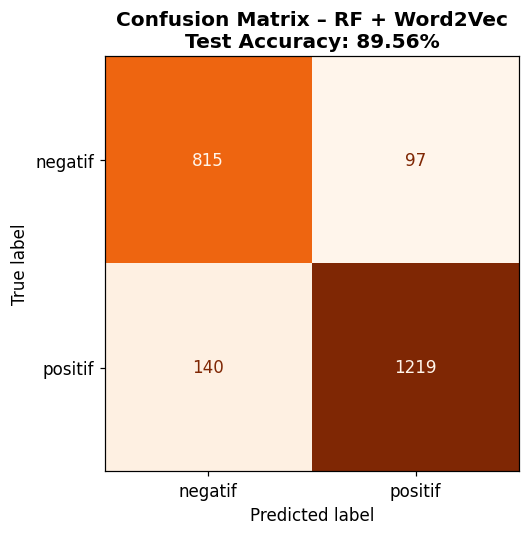

In [ ]:
print("SKEMA 2: Random Forest + Word2Vec")

rf_model = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_model.fit(X_train_w2v, y_train)


y_pred_rf_train = rf_model.predict(X_train_w2v)
y_pred_rf_test  = rf_model.predict(X_test_w2v)

acc_rf_train = accuracy_score(y_train, y_pred_rf_train)
acc_rf_test  = accuracy_score(y_test,  y_pred_rf_test)


print(f"Akurasi Train   : {acc_rf_train:.4f} ({acc_rf_train*100:.2f}%)")
print(f"Akurasi Test    : {acc_rf_test:.4f}  ({acc_rf_test*100:.2f}%)")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_rf_test, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title(f"Confusion Matrix – RF + Word2Vec\nTest Accuracy: {acc_rf_test*100:.2f}%",
             fontweight="bold")
plt.tight_layout()
plt.show()

results_scheme2 = {
    "Skema":         "RF + Word2Vec",
    "Akurasi Train": acc_rf_train,
    "Akurasi Test":  acc_rf_test,
}


---
## Skema 3: IndoBERT Transformer – Deep Learning (Split 80/20)

**Model:** `indobenchmark/indobert-base-p1`  


In [18]:
# Untuk BERT pakai teks yang sudah dibersihkan tapi tidak di stem agar konteks terjaga
tqdm.pandas(desc="Clean (no stem)")
df["bert_text"] = df["review"].progress_apply(lambda x: preprocess(x, do_stem=False))

X_bert = df["bert_text"].values
y_bert = df["label"].values

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert
)
print(f"BERT Train: {len(X_train_bert):,}  |  Test: {len(X_test_bert):,}")


Clean (no stem): 100%|██████████| 11355/11355 [00:00<00:00, 12313.85it/s]

BERT Train: 9,084  |  Test: 2,271


In [ ]:
MODEL_NAME  = "indobenchmark/indobert-base-p1"
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 5
LR          = 2e-5
NUM_LABELS  = 2

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class GojekDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = GojekDataset(X_train_bert, y_train_bert, bert_tokenizer, MAX_LEN)
test_dataset  = GojekDataset(X_test_bert,  y_test_bert,  bert_tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [30]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir="./bert_output",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
)


trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

# Gunakan best model dari Trainer
bert_model = trainer.model
bert_model.to(DEVICE)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 342.70it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.341582,0.318296,0.892558
2,0.212608,0.273160,0.916336
3,0.141055,0.292665,0.918538
4,0.088754,0.379543,0.911933
5,0.056069,0.433741,0.911493


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.57s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

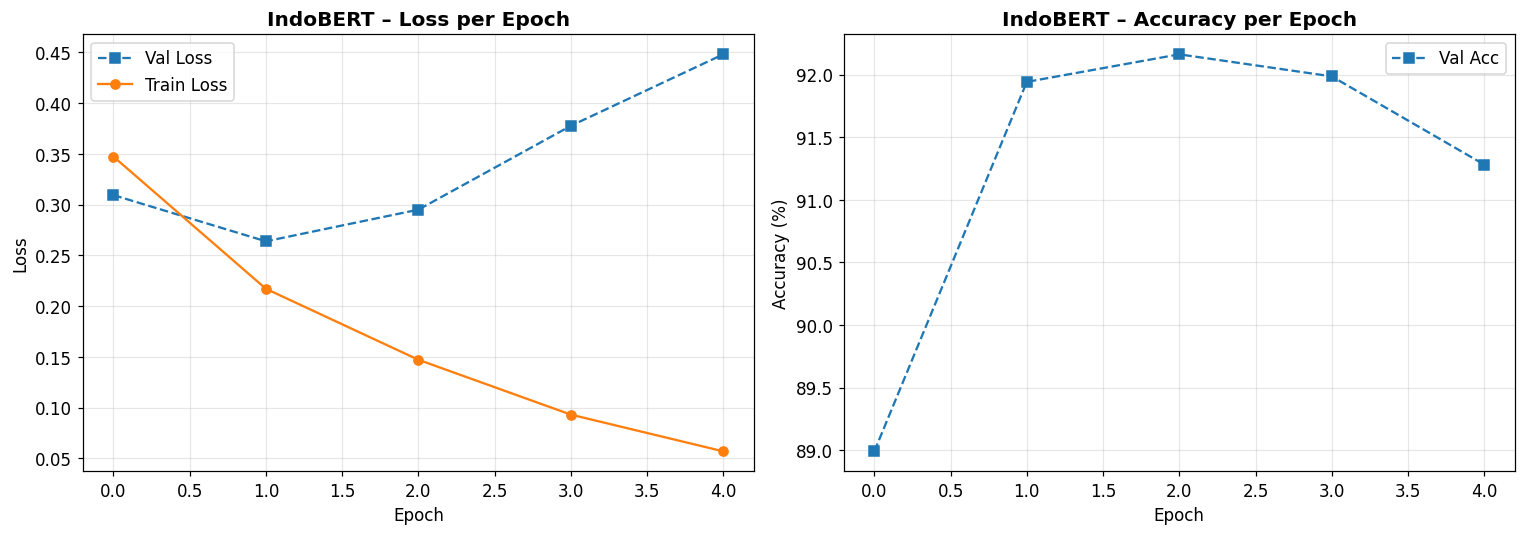


Akurasi Val Terbaik (Trainer): 0.9128 (91.28%)
Akurasi Test                 : 0.9207  (92.07%)

Classification Report (Test):
              precision    recall  f1-score   support

     negatif       0.89      0.92      0.90       912
     positif       0.94      0.92      0.93      1359

    accuracy                           0.92      2271
   macro avg       0.92      0.92      0.92      2271
weighted avg       0.92      0.92      0.92      2271



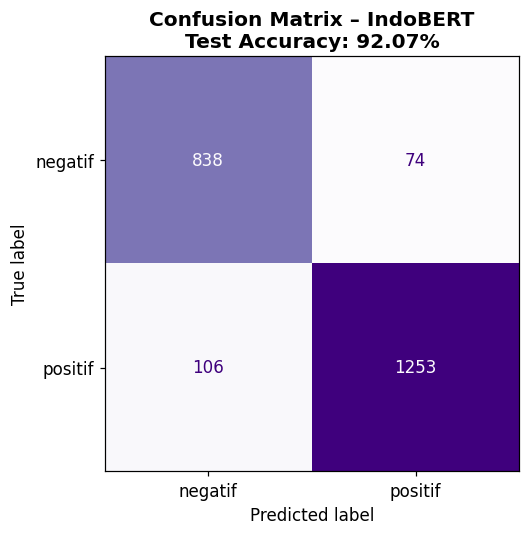

In [23]:
log = trainer.state.log_history

train_entries = [e for e in log if "loss" in e and "eval_loss" not in e]
eval_entries  = [e for e in log if "eval_loss" in e]

history = {
    "train_loss": [e["loss"]              for e in train_entries],
    "train_acc":  [e.get("train_accuracy", e.get("accuracy", 0)) for e in train_entries],
    "val_loss":   [e["eval_loss"]         for e in eval_entries],
    "val_acc":    [e["eval_accuracy"]     for e in eval_entries],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["val_loss"], "s--", marker="s", label="Val Loss")
if history["train_loss"]:
    axes[0].plot(history["train_loss"], "o-", label="Train Loss")
axes[0].set_title("IndoBERT – Loss per Epoch", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot([a * 100 for a in history["val_acc"]], "s--", marker="s", label="Val Acc")
if any(a > 0 for a in history["train_acc"]):
    axes[1].plot([a * 100 for a in history["train_acc"]], "o-", label="Train Acc")
axes[1].set_title("IndoBERT – Accuracy per Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



pred_output = trainer.predict(test_dataset)
all_preds_bert  = np.argmax(pred_output.predictions, axis=-1).tolist()
all_labels_bert = pred_output.label_ids.tolist()

acc_bert_test      = accuracy_score(all_labels_bert, all_preds_bert)
y_pred_bert_train_acc = history["val_acc"][-1] if history["val_acc"] else 0.0

print(f"\nAkurasi Val Terbaik (Trainer): {y_pred_bert_train_acc:.4f} ({y_pred_bert_train_acc*100:.2f}%)")
print(f"Akurasi Test                 : {acc_bert_test:.4f}  ({acc_bert_test*100:.2f}%)")
print("\nClassification Report (Test):")
print(classification_report(all_labels_bert, all_preds_bert, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(all_labels_bert, all_preds_bert)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Purples")
ax.set_title(f"Confusion Matrix – IndoBERT\nTest Accuracy: {acc_bert_test*100:.2f}%",
             fontweight="bold")
plt.tight_layout()
plt.show()

results_scheme3 = {
    "Skema":         "IndoBERT Transformer",
    "Akurasi Train": y_pred_bert_train_acc,
    "Akurasi Test":  acc_bert_test
}


---
## Perbandingan Ketiga Skema

PERBANDINGAN SELURUH SKEMA


,Skema,Akurasi Train (%),Akurasi Test (%)
0,SVM + TF-IDF,96.610000,90.530000
1,RF + Word2Vec,99.140000,89.560000
2,IndoBERT Transformer,91.280000,92.070000


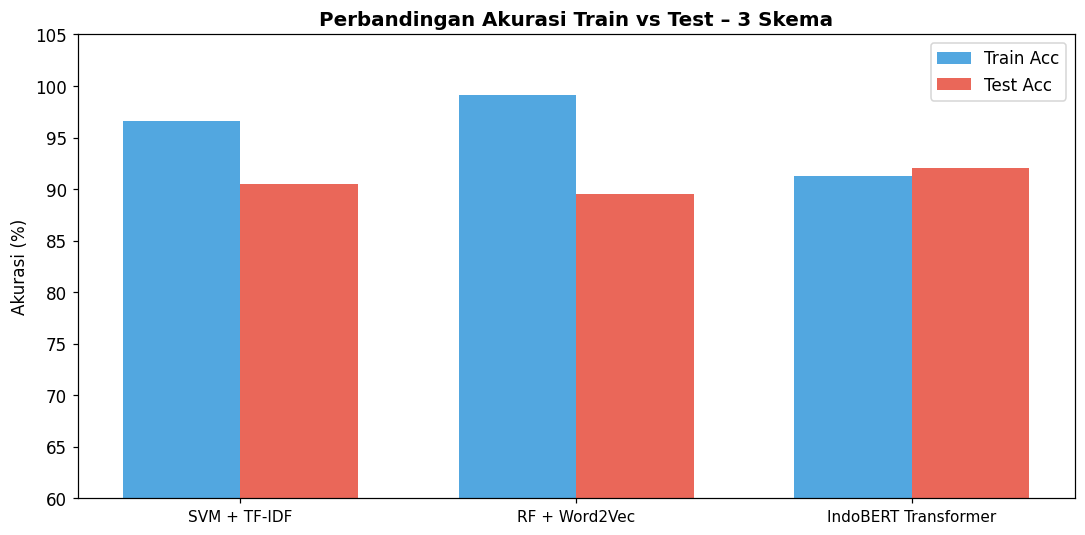

In [34]:
summary = pd.DataFrame([results_scheme1, results_scheme2, results_scheme3])
summary["Akurasi Train (%)"] = (summary["Akurasi Train"] * 100).round(2)
summary["Akurasi Test (%)"]  = (summary["Akurasi Test"]  * 100).round(2)
display_cols = ["Skema", "Akurasi Train (%)", "Akurasi Test (%)"]

print("PERBANDINGAN SELURUH SKEMA")
display(summary[display_cols].style
        .highlight_max(subset=["Akurasi Test (%)"], color="#aaffaa")
        .set_caption("Ringkasan Akurasi"))


fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
width = 0.35

bars1 = ax.bar(x - width/2, summary["Akurasi Train (%)"], width, label="Train Acc", color="#3498db", alpha=0.85)
bars2 = ax.bar(x + width/2, summary["Akurasi Test (%)"],  width, label="Test Acc",  color="#e74c3c", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(summary["Skema"], fontsize=10)
ax.set_ylabel("Akurasi (%)")
ax.set_title("Perbandingan Akurasi Train vs Test – 3 Skema", fontsize=13, fontweight="bold")
ax.set_ylim(60, 105)
ax.legend()

plt.tight_layout()
plt.show()



---
## Inference & Prediksi

Berikut adalah demonstrasi inferensi ketiga model pada teks baru.  
Output berupa kelas kategorikal: **Positif / Negatif**.

In [ ]:
def predict_svm(text: str) -> str:
    cleaned = preprocess(text, do_stem=True)
    vec = tfidf.transform([cleaned])
    pred = svm_model.predict(vec)[0]
    return pred.upper()  

def predict_rf(text: str) -> str:
    cleaned = preprocess(text, do_stem=True)
    vec = text_to_w2v(cleaned, w2v).reshape(1, -1)
    pred = rf_model.predict(vec)[0]
    return pred.upper()  

def predict_bert(text: str) -> str:
    bert_model.eval()
    cleaned = preprocess(text, do_stem=False)
    enc = bert_tokenizer(
        cleaned, max_length=MAX_LEN, padding="max_length",
        truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        out = bert_model(
            input_ids=enc["input_ids"].to(DEVICE),
            attention_mask=enc["attention_mask"].to(DEVICE)
        )
    pred = out.logits.argmax(dim=-1).item()
    return le.classes_[pred].upper()

sample_texts = [
    "Aplikasi ini sangat bagus dan memudahkan aktivitas sehari-hari saya, terima kasih Gojek!",
    "Biasa saja, tidak ada yang istimewa dari aplikasi ini.",
    "Sangat mengecewakan! Aplikasi sering error dan driver tidak profesional. Minta refund!",
    "Gojek terbaik dari semua ojek online, harga terjangkau dan driver ramah.",
    "Driver tidak datang tapi uang sudah dipotong. Layanan pelanggan tidak responsif.",
    "Cukup oke lah, ada kelebihan dan kekurangannya."
]


print(f"{'TEKS ULASAN':<50} {'SVM':^12} {'RF':^12} {'IndoBERT':^12}")
for text in sample_texts:
    short = text[:47] + "..." if len(text) > 50 else text.ljust(50)
    s1 = predict_svm(text)
    s2 = predict_rf(text)
    s3 = predict_bert(text)
    print(f"{short:<50} {s1:^12} {s2:^12} {s3:^12}")

TEKS ULASAN                                            SVM           RF        IndoBERT  
Aplikasi ini sangat bagus dan memudahkan aktivi...   POSITIF      POSITIF      POSITIF   
Biasa saja, tidak ada yang istimewa dari aplika...   POSITIF      POSITIF      POSITIF   
Sangat mengecewakan! Aplikasi sering error dan ...   POSITIF      NEGATIF      NEGATIF   
Gojek terbaik dari semua ojek online, harga ter...   POSITIF      POSITIF      POSITIF   
Driver tidak datang tapi uang sudah dipotong. L...   POSITIF      NEGATIF      NEGATIF   
Cukup oke lah, ada kelebihan dan kekurangannya.      POSITIF      POSITIF      POSITIF   


In [28]:
# SVM predictions
y_pred_svm_labels = [p.upper() for p in y_pred_svm_test]

# RF predictions
y_pred_rf_labels = [p.upper() for p in y_pred_rf_test]
# BERT predictions
y_pred_bert_labels = [le.classes_[p].upper() for p in all_preds_bert]

# Ground truth
y_true_labels = [p.upper() for p in y_test]

df_test_results = pd.DataFrame({
    "review":             X_test_text,
    "true_label":         y_true_labels,
    "pred_svm_tfidf":     y_pred_svm_labels,
    "pred_rf_w2v":        y_pred_rf_labels,
    "pred_indobert":      y_pred_bert_labels,
})

display(df_test_results.head(20))
print(f"\nTotal test samples: {len(df_test_results):,}")

df_test_results.to_csv("hasil_inferensi_test.csv", index=False, encoding="utf-8-sig")

,review,true_label,pred_svm_tfidf,pred_rf_w2v,pred_indobert
0,driver mengcancel order tunggu gonta ganti dri...,NEGATIF,NEGATIF,NEGATIF,NEGATIF
1,bantu,POSITIF,POSITIF,POSITIF,POSITIF
2,cepat murah,POSITIF,POSITIF,POSITIF,POSITIF
3,bantu,POSITIF,POSITIF,POSITIF,POSITIF
4,sebel susah banget gocar jam sibuk kl cuaca me...,NEGATIF,NEGATIF,NEGATIF,NEGATIF
5,keinget jaman bakar bakar duit kuliah gratis o...,POSITIF,NEGATIF,NEGATIF,POSITIF
6,oke,POSITIF,POSITIF,POSITIF,POSITIF
7,guna,POSITIF,POSITIF,POSITIF,POSITIF
8,mudah,POSITIF,POSITIF,POSITIF,POSITIF
9,lawak bgt knp loading mulu jaring aman wifi da...,POSITIF,NEGATIF,NEGATIF,NEGATIF



Total test samples: 2,271
